# 11 — Final Prediction Validation

Produces the final convex hull plots and sublattice occupancy predictions for the complex TCP phases. Generates the main paper figures.

## Prerequisites / Input files
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/results/PREDICTION__*.csv` — prediction CSVs (included in repo)
- `Fe-Mo/data/Validation/DFT_validation_inchull_{phase}.csv`

## Outputs
- Main paper figures in `Fe-Mo/graphs/`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import os

In [2]:
import shutil
import subprocess


def has_full_texlive():
    required_bins = ("latex", "dvipng", "gs", "kpsewhich")
    if any(shutil.which(binary) is None for binary in required_bins):
        return False

    # Verify key LaTeX files are discoverable in the TeX installation.
    required_files = ("article.cls", "type1cm.sty")
    for tex_file in required_files:
        result = subprocess.run(
            ["kpsewhich", tex_file],
            check=False,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0 or not result.stdout.strip():
            return False

    return True


usetex_enabled = has_full_texlive()
if not usetex_enabled:
    print("TeX Live full feature set not detected; using Matplotlib text rendering.")

plt.rc("text", usetex=usetex_enabled)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)

In [3]:
from ase import Atoms

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
dataset = 'Fe-Mo/validation_data/'

In [6]:
dataset_file = os.path.join(dataset, 'FullyCuratedParsedBriefSummary.json')

In [7]:
ValidationBS = pd.read_json(dataset_file)

In [8]:
ValidationBS#.head()#.columns

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.0009403500000000001, -0.00018...",...,None,None,None,NaN,NaN,NaN,NaN,0.171448,1.000000,0.000000
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,NM,R-AAAAAABAABB,R,VASP_PBE_500_0.125_0.1_NM/FeMo/R/Fe_pv39Mo_sv1...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-471.893007,"[[0.0, 0.0, 0.0], [0.00065508, 0.00039792, 0.0...",...,None,None,None,NaN,NaN,NaN,NaN,0.006513,0.735849,0.264151
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539000000000003, -0.0001...",...,None,None,None,NaN,NaN,NaN,NaN,0.108389,0.857143,0.142857
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,None,None,None,NaN,NaN,NaN,NaN,0.042320,0.357143,0.642857
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.0008108400000000001, 0.00079078, -0.00207...",...,None,None,None,NaN,NaN,NaN,NaN,0.120397,0.928571,0.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM,NM,bulk P-BBBBBBBBBBAB,P,None,None,None,None,None,NaN,None,...,251.998072 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0,0.144182,0.142857,0.857143
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,NM,bulk delta-BBBBBBBBABBABB,delta,None,None,None,None,None,NaN,None,...,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0,0.164806,0.142857,0.857143
Mo_sv52.M.NM,NM,bulk M,M,None,None,None,None,None,NaN,None,...,238.686723 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,1.0,0.316807,1.000000,0.000000
Mo_sv56.P.NM,NM,bulk P,P,None,None,None,None,None,NaN,None,...,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,1.0,0.243053,1.000000,0.000000


In [9]:
prediction_data_files = glob.glob('Fe-Mo/results/PREDICTION__*')

In [10]:
prediction_data_files

['Fe-Mo/results/PREDICTION__R__0.7dprojections_0.5os_16_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__P__0.7dprojections_0.5os_16_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__M__0.7dprojections_0.5os_16_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__R__ACE_lmax=321_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__P__ACE_lmax=321_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__M__ACE_lmax=321_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__R__SOAP_specific_small_specific_small_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__P__SOAP_specific_small_specific_small_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific_small_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__M__SOAP_specific_small_specific_small_MAG=0.csv']

In [11]:
PredictionValues = {}

In [12]:
for file in prediction_data_files:
    if 'old' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    PredictionValues[(model_with_params, phase)] = pd.read_csv(file, header=0, index_col=0)

# comparisons

In [13]:
def get_confidence_intervals (regression_model, x, y, n_bootstraps = 1000 ):
    bootstrapped_predictions = np.empty((n_bootstraps, len(x)))
    for i in range(n_bootstraps):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        # Fit the model to the resampled data
        regression_model.fit(x_resampled.reshape(-1, 1), y_resampled)
        # Predict
        bootstrapped_predictions[i] = regression_model.predict(x.reshape(-1, 1))
        lower_ci = np.percentile(bootstrapped_predictions, 2.5, axis=0)
        upper_ci = np.percentile(bootstrapped_predictions, 97.5, axis=0)
    return lower_ci, upper_ci

In [14]:
def plot_with_ci(ytrue, ypred, ax = None):
    sorter = ytrue.values.argsort()
    regressor = LinearRegression()
    regressor.fit(ytrue.values.reshape(-1,1), ypred.values.reshape(-1,1))
    x_y_y = regressor.predict(ytrue.values.reshape(-1,1))
    lower_ci, upper_ci = get_confidence_intervals(LinearRegression(), ytrue.values.astype(float), ypred.values.astype(float))
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(ytrue.values, x_y_y.ravel(), color='tab:blue')#, upper_ci)
    ax.fill_between(ytrue.values.astype(float)[sorter], lower_ci[sorter], upper_ci[sorter], alpha=0.5, color='tab:orange')
    ax.scatter(ytrue, ypred, color='brown', s=60, ec='k')
    return ax

In [15]:
def get_model_position(modelname):
    if 'projections' in modelname:
        return 0
    elif 'ACE' in modelname:
        return 1
    elif 'SOAP' in modelname:
        return 2

In [16]:
phase_position = {'R': 0, 'P' : 2, 'M': 1, 'delta': 3}

In [17]:
phase_label = {'R': '$R$', 'P': '$P$', 'M': '$M$', 'delta': r'$\delta$'}

In [18]:
rmse_tag = {(0,0): 'rmse = '}

In [19]:
plt.rcParams['figure.figsize']

[6.4, 4.8]

In [25]:
target_name

'EF_nmhcp__0.7dprojections_0.5os_MAG=0'

In [28]:
model

'0.7dprojections_0.5os_16_MAG=0'

In [30]:
model

'SOAP_specific_small_specific_small_MAG=0'

In [31]:
target_name

'EF_nmhcp__SOAP_specific_small_small'

In [32]:
prediction_values

,EF_nmhcp__SOAP_specific_small,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,std_votes
Fe_pv53.R.NM,0.115956,0.065763,0.129884,0.164857,0.160851,0.098842,0.241951,0.010660,0.126275,0.099829,0.060645,0.064808
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,0.096237,0.104417,0.090019,0.097892,0.120140,0.070543,0.133787,0.066985,0.087264,0.106856,0.084467,0.020916
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,0.110719,0.091387,0.111989,0.142839,0.148298,0.084631,0.203137,0.033697,0.118016,0.104195,0.069003,0.046915
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,0.073205,0.070856,0.067602,0.078242,0.091141,0.053241,0.097465,0.057960,0.068058,0.081525,0.065955,0.013951
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.127084,0.131637,0.126826,0.152901,0.112208,0.118632,0.177695,0.113803,0.126841,0.113755,0.096538,0.023163
...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.410597,0.407441,0.440059,0.394675,0.434757,0.435361,0.372589,0.371374,0.406413,0.428935,0.414366,0.025121
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.445924,0.459443,0.452912,0.444546,0.449393,0.451425,0.448302,0.427473,0.444232,0.429348,0.452166,0.010212
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.334032,0.347754,0.331375,0.332032,0.347627,0.335784,0.328805,0.311912,0.329091,0.338452,0.337491,0.010327
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.414357,0.423849,0.421071,0.417804,0.420483,0.418233,0.414671,0.396846,0.410239,0.401064,0.419312,0.008972


0.7dprojections_0.5os R EF_nmhcp__0.7dprojections_0.5os
0.7dprojections_0.5os P EF_nmhcp__0.7dprojections_0.5os
0.7dprojections_0.5os delta EF_nmhcp__0.7dprojections_0.5os
0.7dprojections_0.5os M EF_nmhcp__0.7dprojections_0.5os
ACE R EF_nmhcp__ACE
ACE P EF_nmhcp__ACE
ACE delta EF_nmhcp__ACE
ACE M EF_nmhcp__ACE
SOAP_specific_small R EF_nmhcp__SOAP_specific_small
SOAP_specific_small P EF_nmhcp__SOAP_specific_small
SOAP_specific_small delta EF_nmhcp__SOAP_specific_small


/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/home/mariano/.

SOAP_specific_small M EF_nmhcp__SOAP_specific_small


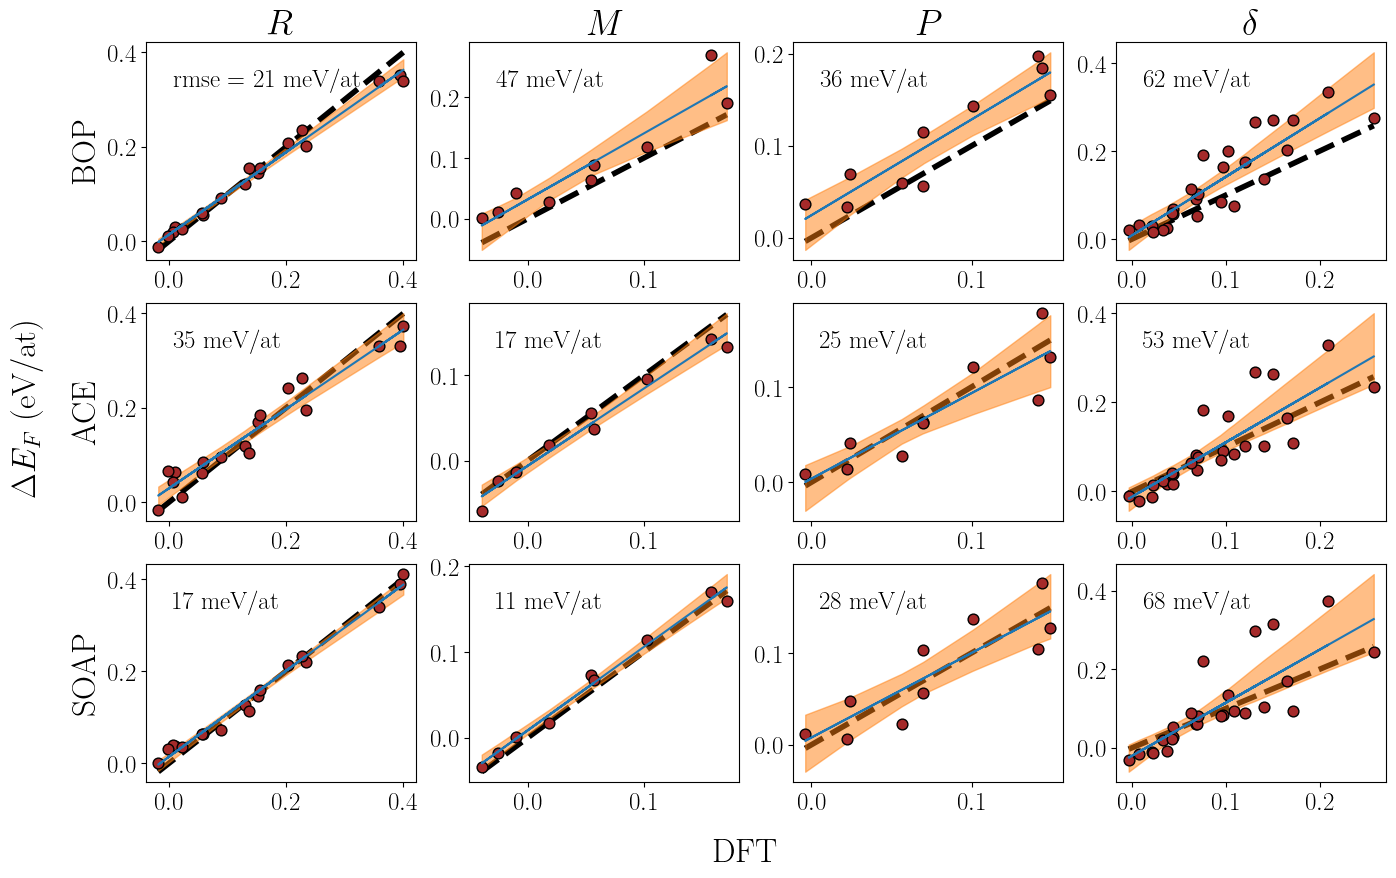

In [33]:
figsize = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(3, len(phase_position), figsize=(figsize[0]*2.5, figsize[1]*2))
rmse = {}
for (model, phase), prediction_values in PredictionValues.items():
    model_name = model.replace('_16','').replace('_lmax=321','').replace('_small_specific','').replace('_MAG=0', '')
    target_name = f'EF_nmhcp__{model_name}'
    print(model_name, phase, target_name)
    this_validation_data = ValidationBS.query('Phase == "'+phase+'"')['EF']
    this_validation_data = this_validation_data.loc[~this_validation_data.index.duplicated(keep='first')]
    predictions_with_validation = prediction_values.index.intersection(this_validation_data.index)
    ytrue = this_validation_data[predictions_with_validation]
    ypred = prediction_values[target_name][predictions_with_validation]
    rmse[(model, phase)] = mean_squared_error(ytrue, ypred, squared=False)
    this_rmse = rmse[(model, phase)]
    I = get_model_position(model_name)
    J = phase_position[phase]
    ax[I,J] = plot_with_ci(ytrue, ypred, ax=ax[I,J])
    this_rmse_label = rf'{rmse_tag.get((I,J), "")}{this_rmse*1000 :.0f} meV/at'
    ax[I,J].annotate(this_rmse_label,(0.1, 0.8), xycoords='axes fraction', fontsize = 18)
    if I == 0:
        ax[I,J].set_title(phase_label.get(phase), fontsize = 26)
    ax[I,J].plot([ytrue.min(), ytrue.max()], [ytrue.min(), ytrue.max()], '--k', linewidth=4, zorder = -10)
ylabel_bop =ax[get_model_position('projections'),0].set_ylabel('BOP', fontsize=24)
ylabel_ACE =ax[get_model_position('ACE'), 0].set_ylabel('ACE', fontsize=24)
ylabel_SOAP =ax[get_model_position('SOAP'), 0].set_ylabel('SOAP', fontsize=24)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supxlabel('DFT', fontsize=24, y=0.02)
fig.supylabel('$\Delta E_F$ (eV/at)', fontsize=24, x=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_Predictions_Validation.pdf')

In [61]:
rmse = pd.Series(rmse)

In [62]:
rmse.to_json('Fe-Mo/data/Validation/rmse.json', indent = True)

In [65]:
rmse = pd.read_json('Fe-Mo/data/Validation/rmse.json', typ='series', orient='index')

# DFT convex hulls from Validation calculations

In [34]:
from Tools.DatasetTools.Tools import Plotting

In [36]:
BS = pd.read_json('Fe-Mo/FullyCuratedParsedBriefSummary.json')

In [37]:
P = Plotting()

In [38]:
ValidationBS.Phase.value_counts()

Phase
delta    28
R        19
P        12
M        11
Name: count, dtype: int64

In [39]:
BS = BS.rename(columns = {'Fe_pv': 'x_Fe', 'Mo_sv': 'x_Mo', 'EF_nmhcp': 'EF'})

In [41]:
CHULLS_DFT_V = {}
plottables = {}
all_vertices_low={}
for phase, phasedata in ValidationBS.groupby('Phase'):
    plottables[phase] = pd.concat([
        phasedata[['x_Fe', 'EF', 'nelem' ]], 
        BS.query(f'Phase == "{phase}"')[['x_Fe', 'EF', 'nelem' ]]
    ], axis = 0).sort_values(by=['x_Fe', 'EF']).fillna(2)
    phase_chull = P.get_convex_hulls(
        {phase: plottables[phase]}, ['x_Fe'], getproperty='EF', viewpoint=(0.6, -10)
    )
    all_vertices_low[phase]= np.unique(
        np.hstack(phase_chull[phase].simplices[phase_chull[phase].good])
    )
    CHULLS_DFT_V[phase] = plottables[phase].iloc[all_vertices_low[phase]]

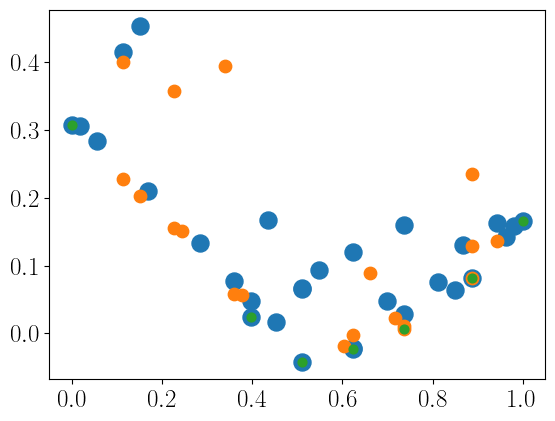

In [42]:
plt.scatter(BS.query('Phase == "R"')['x_Fe'],BS.query('Phase == "R"')['EF'], s = 150)
plt.scatter(ValidationBS.query('Phase == "R"')['x_Fe'],ValidationBS.query('Phase == "R"')['EF'], s = 80)
plt.scatter(CHULLS_DFT_V['R']['x_Fe'], CHULLS_DFT_V['R']['EF'], s = 40)

# save DFT chulls

In [44]:
for phase, chull in CHULLS_DFT_V.items():
    chull_file = f'Fe-Mo/data/Validation/DFT_validation_inchull_{phase}.csv'
    chull.to_csv(chull_file)

# not sure what i do here.

In [45]:
for (model, phase), prediction_values in PredictionValues.items():
    break

In [46]:
sorted_validation = ValidationBS.query(f'Phase == "{phase}"').sort_values(by='x_Fe')

In [47]:
validated_samples = prediction_values.index.intersection(sorted_validation.index)

In [48]:
prediction_values.loc[validated_samples]

,EF_nmhcp__0.7dprojections_0.5os,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,vote_10,vote_11,std_votes
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,0.120508,0.124787,0.117276,0.124083,0.123336,0.098143,0.077905,0.127713,0.131305,0.150979,0.142925,0.086666,0.140977,0.022418
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM,0.028989,0.017802,0.023829,0.028735,0.018243,0.002128,0.059795,0.024045,0.038660,0.025632,0.021721,0.062899,0.024375,0.017297
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,0.018959,0.005237,0.011331,0.015188,0.024751,0.032178,0.006672,0.008099,0.021875,0.012982,0.006680,0.080978,0.001540,0.021496
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM,0.011934,-0.007974,0.009506,0.001854,0.004982,0.029531,0.043152,-0.002508,0.004646,0.002755,-0.014265,0.071710,-0.000182,0.024474
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM,0.091874,0.065836,0.102372,0.041198,0.075581,0.071640,0.124056,0.078270,0.089205,0.104986,0.071167,0.182774,0.095404,0.035847
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM,0.201663,0.253954,0.166960,0.200960,0.201523,0.167400,0.197626,0.181077,0.234376,0.216106,0.210506,0.175475,0.213990,0.026540
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,0.054470,0.060224,0.056269,0.052383,0.054428,0.048469,0.031493,0.055319,0.044602,0.054854,0.056548,0.082279,0.056778,0.011622
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,0.144279,0.136842,0.150000,0.139623,0.157341,0.143309,0.114815,0.152977,0.142298,0.147952,0.146921,0.147302,0.151971,0.010945
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM,0.155586,0.120685,0.219745,0.192127,0.154197,0.226934,0.084922,0.112904,0.143026,0.212645,0.160750,0.109641,0.129462,0.047492
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM,0.025621,0.013539,0.035100,0.017455,0.031516,0.046972,0.036389,0.036049,0.020561,0.012084,0.025817,0.011625,0.020340,0.011483


In [53]:
prediction_values.loc[validated_samples]['EF_nmhcp__0.7dprojections_0.5os']

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.120508
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.028989
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.018959
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.011934
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.091874
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.201663
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.054470
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.144279
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.155586
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.025621
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM   -0.011662
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.059842
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.208820
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.154390
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.234958
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.351847
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.339786
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.339329
Name: EF_nmhcp__0.7dprojections_0.5os, dtype: float64

In [54]:
ValidationBS.loc[validated_samples]['x_Fe']

Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM     0.886792
Fe_pv39Mo_sv14.R-AAAAAAABABB.NM    0.735849
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM    0.735849
Fe_pv33Mo_sv20.R-AAAAAABBABB.NM    0.622642
Fe_pv35Mo_sv18.R-AAAAAABBBAA.NM    0.660377
Fe_pv47Mo_sv6.R-AAAABAAAAAA.NM     0.886792
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM    0.358491
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM    0.245283
Fe_pv50Mo_sv3.R-BAAAAAAAABA.NM     0.943396
Fe_pv38Mo_sv15.R-BAAAAAAABBB.NM    0.716981
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM    0.603774
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM    0.377358
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM     0.150943
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBABBBBB.NM     0.113208
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM    0.339623
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM    0.226415
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM     0.113208
Name: x_Fe, dtype: float64